# MLOPS

In [ ]:
# Pour Terminal VSCODE seulement
# python -m venv .venv
# source .venv/bin/activate

In [ ]:
from pathlib import Path
import pandas as pd

# 1) Load the dataset from the GitHub URL
url = "https://raw.githubusercontent.com/jiwon-yi/Projet_MLOps/main/Loan_Data.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist()[:8])

(10000, 8)
['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']


In [ ]:
display(df)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [ ]:
display(df)
print(df.describe())

nan_counts = df.isna().sum()
print("NaN :\n", nan_counts)

dup_total = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {dup_total}")

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


        customer_id  credit_lines_outstanding  loan_amt_outstanding  \
count  1.000000e+04              10000.000000          10000.000000   
mean   4.974577e+06                  1.461200           4159.677034   
std    2.293890e+06                  1.743846           1421.399078   
min    1.000324e+06                  0.000000             46.783973   
25%    2.977661e+06                  0.000000           3154.235371   
50%    4.989502e+06                  1.000000           4052.377228   
75%    6.967210e+06                  2.000000           5052.898103   
max    8.999789e+06                  5.000000          10750.677810   

       total_debt_outstanding         income  years_employed    fico_score  \
count            10000.000000   10000.000000    10000.000000  10000.000000   
mean              8718.916797   70039.901401        4.552800    637.557700   
std               6627.164762   20072.214143        1.566862     60.657906   
min                 31.652732    1000.000000    

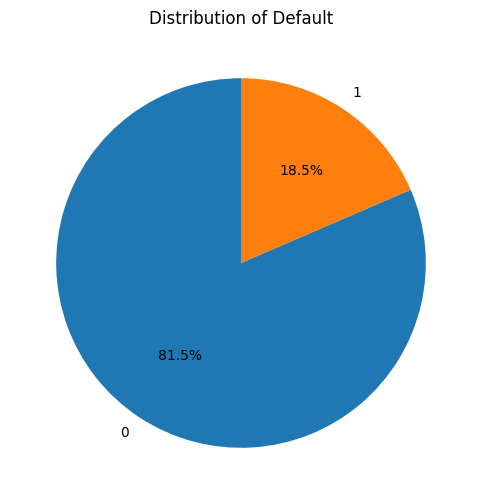

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

default_counts = df['default'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Default')
plt.show()

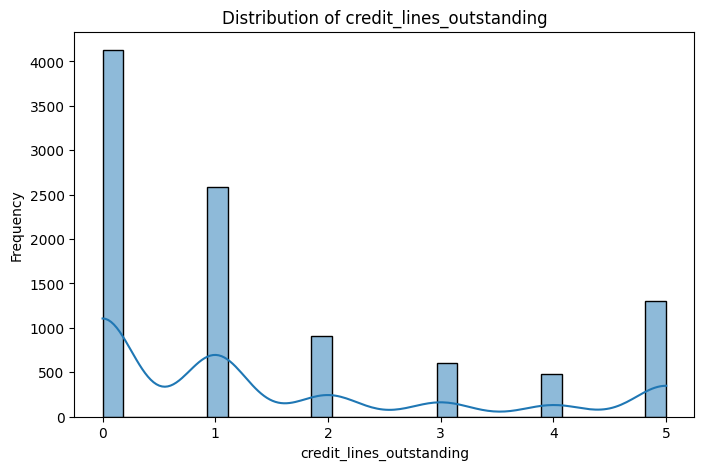

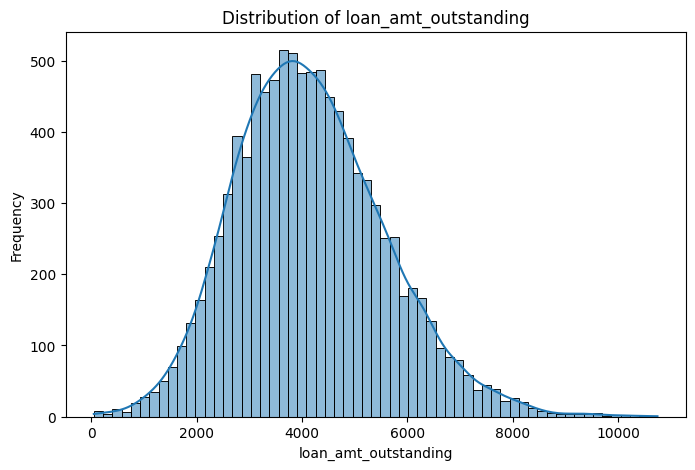

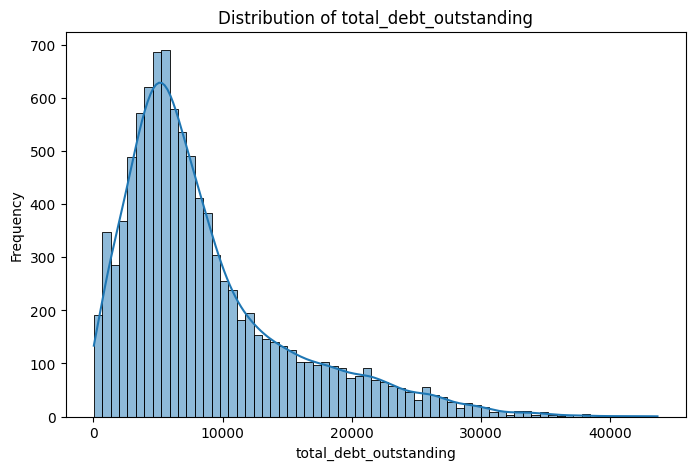

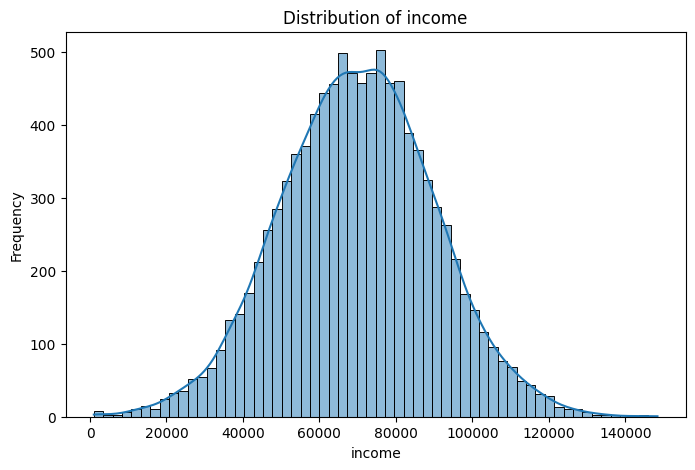

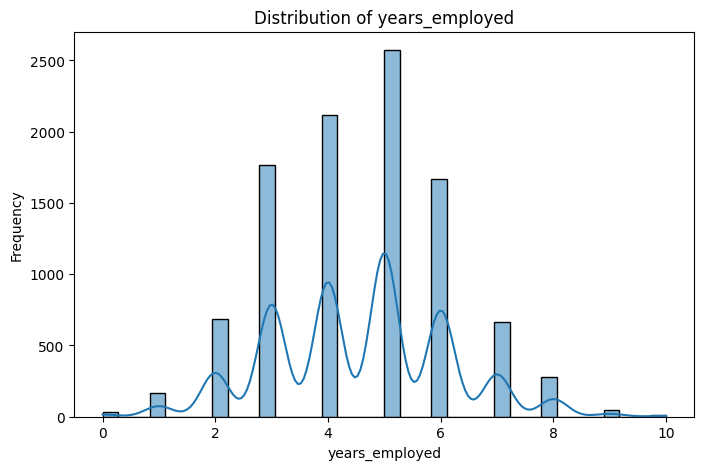

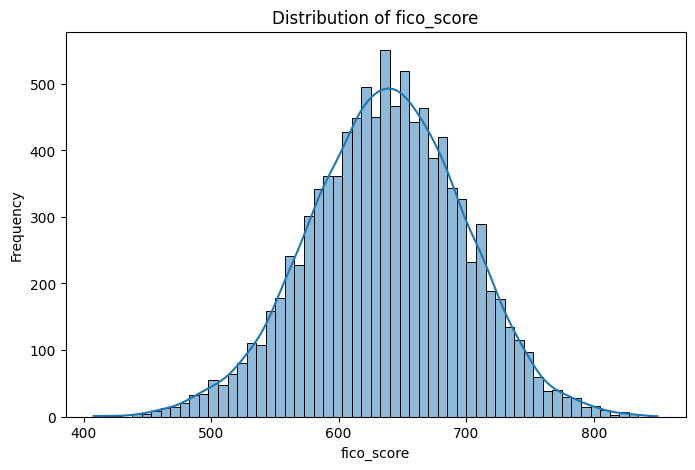

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns (excluding 'customer_id' and 'default' as they are not features for distribution analysis)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('customer_id')
numerical_cols.remove('default')

# Create histograms for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

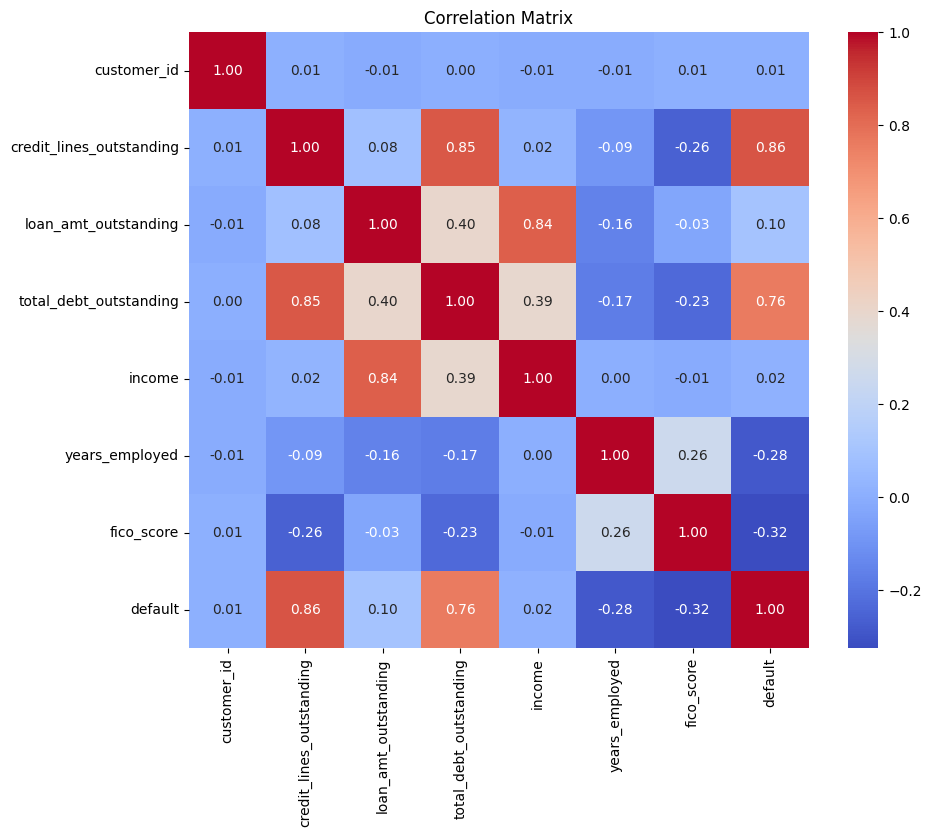

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Create the 'debt_ratio' feature
df['debt_ratio'] = df['total_debt_outstanding'] / df['income']

# Display the first few rows with the new feature
display(df.head())

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,debt_ratio
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.050173
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.308789
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.030787
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.033645
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.075435


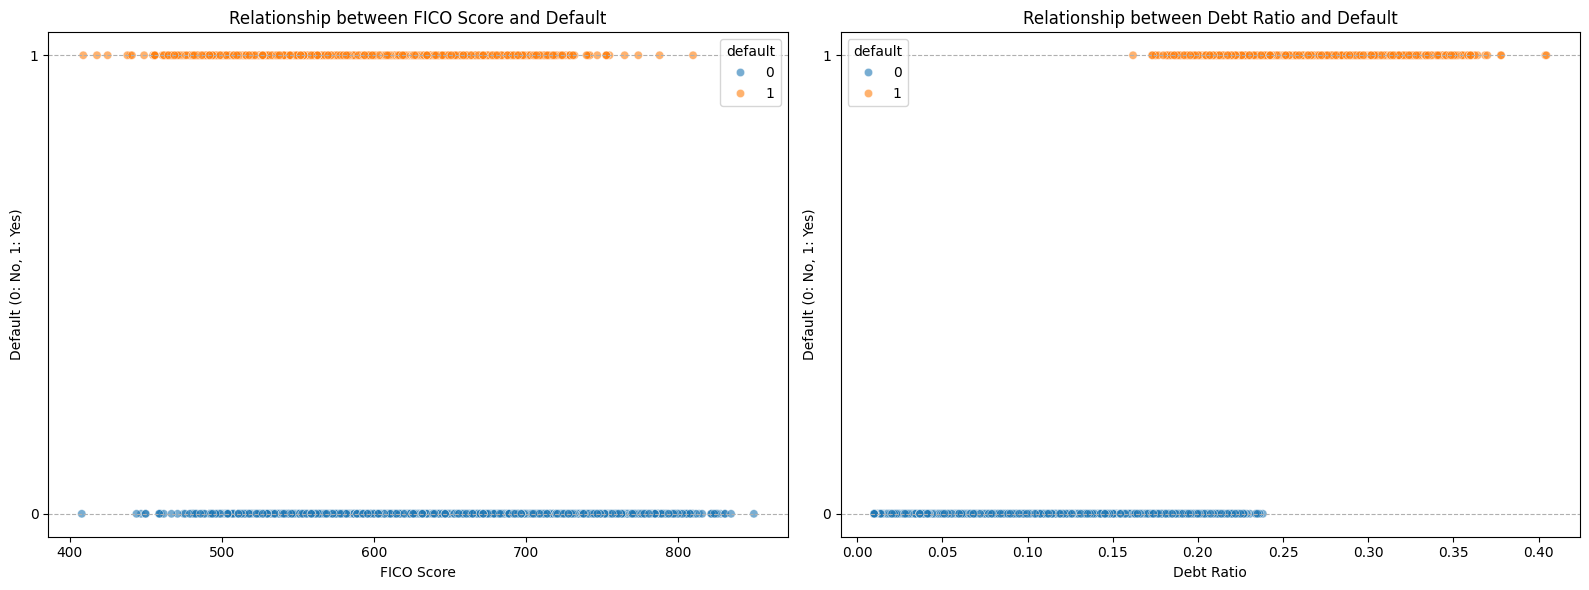

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot of debt_ratio vs default
sns.scatterplot(data=df, x='debt_ratio', y='default', hue='default', alpha=0.6, ax=axes[1])
axes[1].set_title('Relationship between Debt Ratio and Default')
axes[1].set_xlabel('Debt Ratio')
axes[1].set_ylabel('Default (0: No, 1: Yes)')
axes[1].set_yticks([0, 1])
axes[1].grid(axis='y', linestyle='--')

# Scatter plot of fico_score vs default
sns.scatterplot(data=df, x='fico_score', y='default', hue='default', alpha=0.6, ax=axes[0])
axes[0].set_title('Relationship between FICO Score and Default')
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Default (0: No, 1: Yes)')
axes[0].set_yticks([0, 1])
axes[0].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
datasetfinal = df
display(datasetfinal)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,debt_ratio
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,0.050173
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,0.308789
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,0.030787
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0.033645
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0.075435
...,...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0,0.059818
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0,0.068253
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0,0.126021
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0,0.020481


## Dataset Description

This dataset contains information about customer loan applications and their default status. It includes the following columns:

*   **customer\_id**: Unique identifier for each customer.
*   **credit\_lines\_outstanding**: The number of credit lines outstanding for the customer.
*   **loan\_amt\_outstanding**: The amount of the loan outstanding.
*   **total\_debt\_outstanding**: The total amount of debt outstanding for the customer.
*   **income**: The customer's income.
*   **years\_employed**: The number of years the customer has been employed.
*   **fico\_score**: The customer's FICO score, a creditworthiness indicator.
*   **default**: The target variable, indicating whether the customer defaulted on the loan (1 for default, 0 for no default).
*   **debt\_ratio**: The ratio of total debt outstanding to income (calculated feature).

In [ ]:
# Save the DataFrame to a CSV file
datasetfinal.to_csv('datasetfinal.csv', index=False)

print("DataFrame saved to datasetfinal.csv")

DataFrame saved to loan_data_final.csv
